# Initial/starter notebook for analysing stochastic pattern field and MCSP triggers

* Mark Muetzelfeldt, 20/6/2025
* Needs access to the MCS:PRIME GWS on JASMIN
* Uses 3 sims, all run for 10 days from 1/7/2020 with 10 ensemble members (EM0 is deterministic control - ignore):
    * u-dq668 - ctrl, Lbeta=500km
    * u-dq907 - Lbeta=250km (in progress)
    * u-dq961 - Lbeta=1000km (in progress)
* Loads UM data, converts to xarray, calculates all necessary fields/triggers (mirroring calcs in UM source code), plots 3x triggers and full trigger, plus comparison
* Note, "m01s05i993" is technically a 3D field, "org_temp_tendency", but Zhixiao/I have overridden so the first 6 layers contain the diagnostic info we need.
* All fields are instantaneous - no meaning applied

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import iris
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr

/home/users/mmuetz/miniconda3/envs/upflo_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
# ONLY loads em1 - more ensemble members are available if nec.
basedir = Path('/gws/nopw/j04/mcs_prime/mmuetz/data/UM_sims/u-dq907/share/cycle/20200701T0000Z/engl/um/em1')

In [3]:
cubes = iris.load(basedir / 'englaa_pa000.pp')
cubes

[<iris 'Cube' of m01s09i202 / (unknown) (time: 25; latitude: 324; longitude: 432)>,
<iris 'Cube' of cloud_area_fraction_assuming_only_consider_surface_to_1000_feet_asl / (1) (time: 25; latitude: 324; longitude: 432)>,
<iris 'Cube' of m01s09i233 / (unknown) (time: 25; latitude: 324; longitude: 432)>,
<iris 'Cube' of m01s01i202 / (unknown) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of Turbulent mixing height after boundary layer / (m) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of Cumulus capped boundary layer indicator / (1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of m01s03i465 / (unknown) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of m01s03i476 / (unknown) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of m01s05i991 / (unknown) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of m01s05i993 / (unknown) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of m01s05i994 / (unknown) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of cloud_base_altitude_assuming_only_consider_cloud_area_fraction_greater_than_2p5_oktas / (kft) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of cloud_area_fraction_assuming_maximum_random_overlap / (1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of m01s30i461 / (unknown) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of m01s05i992 / (unknown) (time: 24; model_level_number: 6; latitude: 324; longitude: 432)>,
<iris 'Cube' of air_pressure_at_sea_level / (Pa) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of air_temperature / (K) (time: 25; latitude: 324; longitude: 432)>,
<iris 'Cube' of atmosphere_cloud_ice_content / (kg m-2) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of atmosphere_cloud_liquid_water_content / (kg m-2) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of convective_rainfall_flux / (kg m-2 s-1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of convective_rainfall_flux / (kg m-2 s-1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of convective_snowfall_flux / (kg m-2 s-1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of convective_snowfall_flux / (kg m-2 s-1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of high_type_cloud_area_fraction / (1) (time: 25; latitude: 324; longitude: 432)>,
<iris 'Cube' of land_binary_mask / (1) (latitude: 324; longitude: 432)>,
<iris 'Cube' of low_type_cloud_area_fraction / (1) (time: 25; latitude: 324; longitude: 432)>,
<iris 'Cube' of medium_type_cloud_area_fraction / (1) (time: 25; latitude: 324; longitude: 432)>,
<iris 'Cube' of moisture_content_of_soil_layer / (kg m-2) (time: 25; depth: 4; latitude: 324; longitude: 432)>,
<iris 'Cube' of precipitation_flux / (kg m-2 s-1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of precipitation_flux / (kg m-2 s-1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of relative_humidity / (%) (time: 25; latitude: 324; longitude: 432)>,
<iris 'Cube' of stratiform_rainfall_flux / (kg m-2 s-1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of stratiform_rainfall_flux / (kg m-2 s-1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of stratiform_snowfall_flux / (kg m-2 s-1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of stratiform_snowfall_flux / (kg m-2 s-1) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of surface_altitude / (m) (latitude: 324; longitude: 432)>,
<iris 'Cube' of surface_downwelling_longwave_flux_in_air / (W m-2) (time: 23; latitude: 324; longitude: 432)>,
<iris 'Cube' of surface_downwelling_shortwave_flux_in_air / (W m-2) (time: 23; latitude: 324; longitude: 432)>,
<iris 'Cube' of surface_net_downward_longwave_flux / (W m-2) (time: 23; latitude: 324; longitude: 432)>,
<iris 'Cube' of surface_upward_latent_heat_flux / (W m-2) (time: 24; latitude: 324; longitude: 432)>,
<iris 'Cube' of surface_upward_sensible_heat_flux / (W m-2) (time: 24; latitude: 324; long

In [4]:
def extract_org_ad_hoc_diags(cubes):
    """Extract diagnostics that have been stuffed into the first 6 layers of the org_temp_tendency diag.

    code: /home/d02/mamue/projects/vn13.0_org_conv/src/atmosphere/convection/org_conv.F90
    =================
    IF (ALLOCATED(psif2)) THEN
     org_temp_tendency(i,j,1) = psif2(i, j)
    END IF
    org_temp_tendency(i,j,2) = lcbase(i,j)
    org_temp_tendency(i,j,3) = lctop(i,j)
    org_temp_tendency(i,j,4) = p_layer_boundaries(i,j,lctop(i,j))
    org_temp_tendency(i,j,5) = p_layer_boundaries(i,j,lcbase(i,j)-1)
    org_temp_tendency(i,j,6) = lctop_temp
    =================
    """
    da = xr.DataArray.from_iris(cubes.extract_cube('m01s05i992'))
    drop_coords = [c for c in da.coords if c not in da.dims]
    da = da.drop_vars(drop_coords)
    idx_to_name_map = {
        0: 'stoch_pattern',
        1: 'lcbase',
        2: 'lctop',
        3: 'pressure_cbase',
        4: 'pressure_ctop',
        5: 'lctop_temp',
    }
    units = {
        0: '-',
        1: '-',
        2: '-',
        3: 'hPa',
        4: 'hPa',
        5: 'K',
    }
    
    ds = xr.Dataset({
        idx_to_name_map[i]: da.isel(model_level_number=i).drop_vars("model_level_number").assign_attrs({
            'units': units[i]
        })
        for i in range(da.sizes["model_level_number"])
    })
    return ds

def extract_diags(cubes):
    ds = extract_org_ad_hoc_diags(cubes)
    #ds['tcwv'] = xr.DataArray.from_iris(cubes.extract_cube('m01s30i461')).rename(time='time2')
    ds['tcwv'] = xr.DataArray.from_iris(cubes.extract_cube('m01s30i461'))
    ds['deep_trigger'] = xr.DataArray.from_iris(cubes.extract_cube('m01s05i991')).astype(bool)
    ds['full_trigger'] = xr.DataArray.from_iris(cubes.extract_cube('m01s05i993')).astype(bool)
    ds['shear_mag'] = xr.DataArray.from_iris(cubes.extract_cube('m01s05i994'))
    ds['shear_trigger'] = ds.shear_mag > 3  # m s-1, as in scheme.
    
    return ds

def calc_tcwv_prob(tcwv):
    p = 0.009066 * tcwv + 0.199061
    p = xr.where(p > 1, 1, p)
    return p

def calc_pattern_prob(stoch_pattern):
    mu = 0.0
    sigma = 0.26962024
    z = (stoch_pattern - mu) / sigma
    
    return 0.5 * scipy.special.erfc(z / np.sqrt(2.0))

In [5]:
# Create a nice dataset with all the info we can extract from the UM output and some calculated info as well.
ds = extract_diags(cubes)
ds['tcwv_prob'] = calc_tcwv_prob(ds.tcwv)
ds['pattern_prob'] = calc_pattern_prob(ds.stoch_pattern)
ds['stoch_trigger'] = ds.pattern_prob < ds.tcwv_prob
ds

<xarray.Dataset> Size: 148MB
Dimensions:                  (time: 24, latitude: 324, longitude: 432)
Coordinates:
  * time                     (time) datetime64[ns] 192B 2020-07-01T04:00:00 ....
  * latitude                 (latitude) float32 1kB -89.72 -89.17 ... 89.72
  * longitude                (longitude) float32 2kB 0.4167 1.25 ... 358.7 359.6
    realization              int64 8B ...
    forecast_period          (time) timedelta64[ns] 192B ...
    forecast_reference_time  (time) datetime64[ns] 192B ...
Data variables: (12/14)
    stoch_pattern            (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    lcbase                   (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    lctop                    (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    pressure_cbase           (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    pressure_ctop            (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    lctop_temp               (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    ...                       ...
    full_trigger             (time, latitude, longitude) bool 3MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    shear_mag                (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    shear_trigger            (time, latitude, longitude) bool 3MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    tcwv_prob                (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    pattern_prob             (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>
    stoch_trigger            (time, latitude, longitude) bool 3MB dask.array<chunksize=(1, 324, 432), meta=np.ndarray>

In [6]:
def quick_plot(ds, field, title):
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
    im = ax.pcolormesh(ds.longitude, ds.latitude, field)
    plt.colorbar(im, ax=ax, orientation='horizontal')
    ax.coastlines()
    ax.set_title(title)

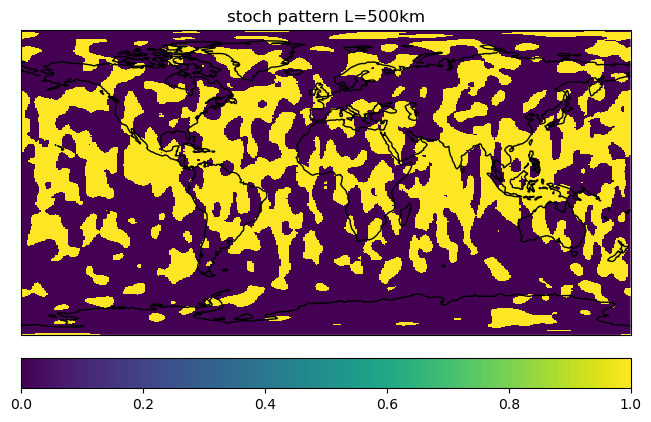

In [7]:
quick_plot(ds, ds.stoch_trigger[1], 'stoch pattern L=500km')

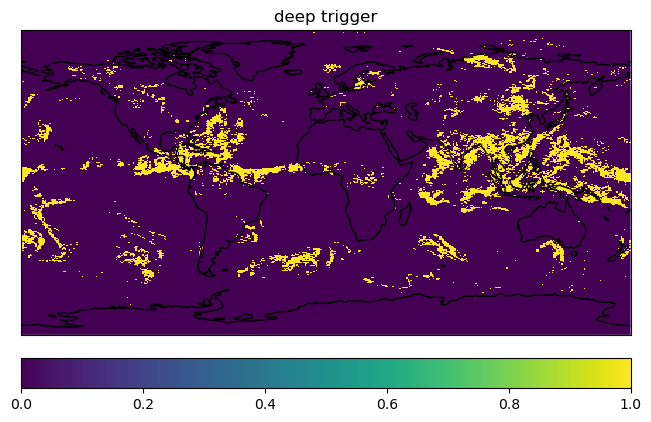

In [8]:
quick_plot(ds, ds.deep_trigger[1], 'deep trigger')

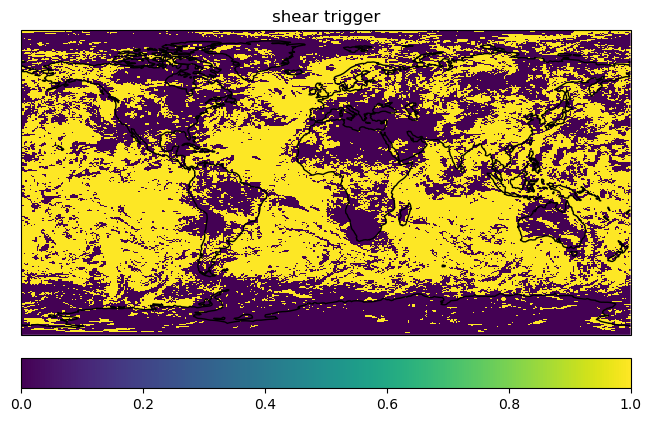

In [9]:
quick_plot(ds, ds.shear_trigger[1], 'shear trigger')

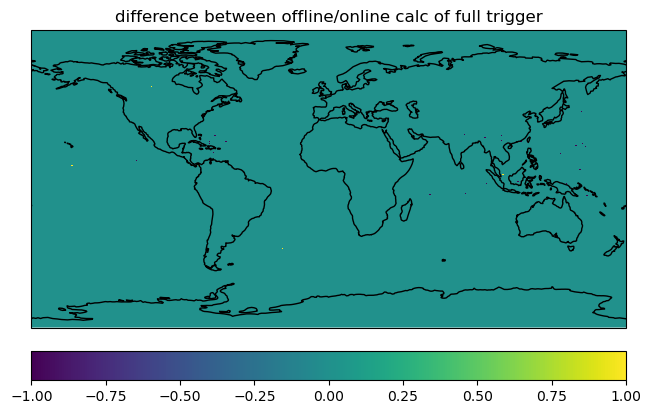

In [10]:
quick_plot(
    ds, 
    (ds.stoch_trigger[1] & ds.deep_trigger[1] & ds.shear_trigger[1]) - ds.full_trigger[1].astype(float),
    'difference between offline/online calc of full trigger',
)

This shows that there are some grid-point differences between the trigger as calculated here (offline) and that calculated by the UM (online).
However, these are very limited, and seem to be restricted to a few isolated grid points. Expect that this is due to e.g. differences between < vs <=, Python vs Fortran, perhaps float32 vs float64, slight differences near threshold values...

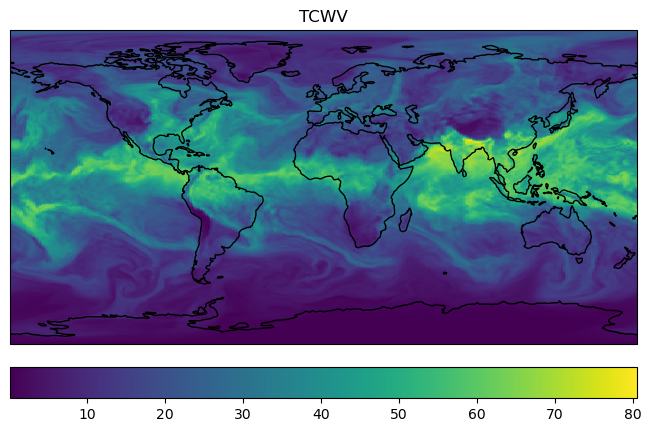

In [11]:
quick_plot(ds, ds.tcwv[1], 'TCWV')

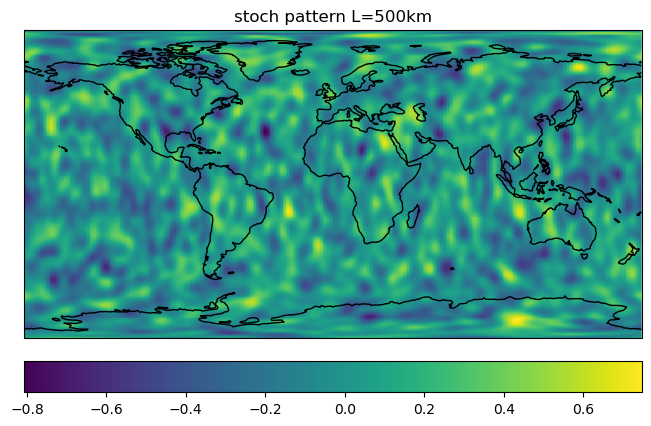

In [12]:
quick_plot(ds, ds.stoch_pattern[1], 'stoch pattern L=500km')